# R군(호흡기계) 성별 분석

In [1]:
!apt-get -qq install fonts-nanum > /dev/null
!pip -q install statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import math
from scipy.stats import chi2_contingency, fisher_exact
import statsmodels.formula.api as smf
from google.colab import files

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False

BURGUNDY = "#7A1F3D"
BURGUNDY_LIGHT = "#C06C84"
BURGUNDY_DARK = "#4A0F23"
GRAY = "#666666"

# 데이터 업로드 및 R군(호흡기계) 필터링
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name, low_memory=False)
print("전체 데이터 크기:", df.shape)

def to_bool(series):
    return series.astype(str).str.strip().str.lower().isin(["true", "1", "yes", "y"])

for col in ["serious", "is_fatal", "is_hospitalized", "is_life_threat", "is_disabling", "patient_recovered"]:
    df[col + "_bool"] = to_bool(df[col])

df["WHO_ATC"] = df["WHO_ATC"].fillna("").astype(str).str.strip().str.upper()
df["ATC_L1"] = df["WHO_ATC"].str[0]
df["num_drugs"] = pd.to_numeric(df["num_drugs"], errors="coerce")
df["num_reactions"] = pd.to_numeric(df["num_reactions"], errors="coerce")
df["patient_age_years"] = pd.to_numeric(df["patient_age_years"], errors="coerce")

r_df = df[df["ATC_L1"] == "R"].copy()
r_df["sex_clean"] = r_df["patient_sex"].fillna("Unknown").astype(str)
r_df["drug_count_category_clean"] = r_df["drug_count_category"].fillna("Unknown").astype(str).str.strip()
r_df["polypharmacy_6plus"] = (r_df["drug_count_category_clean"] == "Polypharmacy(6+)")
r_df["age_risk_group"] = np.where(
    r_df["patient_age_years"].between(13, 40), "13-40세",
    np.where(r_df["patient_age_years"].between(0, 120), "그 외 알려진 연령", "연령 Unknown")
)

print("R군 전체 건수:", len(r_df))
print(r_df["sex_clean"].value_counts())

mf_df = r_df[r_df["sex_clean"].isin(["Male", "Female"])].copy()
print("남성/여성 분석 대상 건수:", len(mf_df))

Saving FDA_adverse_events_final.csv to FDA_adverse_events_final (1).csv
전체 데이터 크기: (18273, 28)
R군 전체 건수: 1562
sex_clean
Female     900
Male       487
Unknown    175
Name: count, dtype: int64
남성/여성 분석 대상 건수: 1387


In [2]:
# 분석 함수 (요약표 / 카이제곱+Cramer's V / 오즈비+95%CI / % 축 포맷)
def rate_summary(data, group_col):
    return (
        data.groupby(group_col)
        .agg(
            n=("serious_bool", "size"),
            serious_rate=("serious_bool", "mean"),
            fatal_rate=("is_fatal_bool", "mean"),
            hospitalized_rate=("is_hospitalized_bool", "mean"),
            life_threat_rate=("is_life_threat_bool", "mean"),
            polypharmacy_rate=("polypharmacy_6plus", "mean"),
            mean_num_reactions=("num_reactions", "mean"),
            median_num_reactions=("num_reactions", "median")
        )
        .reset_index()
    )

def chi_square_test(data, group_col, outcome_col):
    table = pd.crosstab(data[group_col], data[outcome_col])
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.values.sum(); k = min(table.shape)
    cramers_v = np.sqrt(chi2 / (n * (k - 1))) if k > 1 else np.nan
    print("\n[카이제곱 검정]"); print("변수:", group_col, "vs", outcome_col)
    display(table)
    print("chi2:", chi2); print("p-value:", p); print("Cramer's V:", cramers_v)
    return table, chi2, p, cramers_v

def odds_ratio_ci(data, exposure_col, outcome_col, exposure_value="Male", reference_value="Female"):
    temp = data[data[exposure_col].isin([exposure_value, reference_value])].copy()
    a = ((temp[exposure_col] == exposure_value) & (temp[outcome_col])).sum()
    b = ((temp[exposure_col] == exposure_value) & (~temp[outcome_col])).sum()
    c = ((temp[exposure_col] == reference_value) & (temp[outcome_col])).sum()
    d = ((temp[exposure_col] == reference_value) & (~temp[outcome_col])).sum()
    if min(a, b, c, d) == 0:
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    OR = (a * d) / (b * c)
    se = math.sqrt(1/a + 1/b + 1/c + 1/d)
    return OR, math.exp(math.log(OR) - 1.96*se), math.exp(math.log(OR) + 1.96*se)

def percent_axis_y():
    plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

def percent_axis_x():
    plt.gca().xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

In [3]:
# H1. 성별별 주요 결과 비율
sex_summary = rate_summary(r_df, "sex_clean")
display(sex_summary)

for outcome in ["serious_bool", "is_fatal_bool", "is_hospitalized_bool", "is_life_threat_bool"]:
    chi_square_test(mf_df, "sex_clean", outcome)
    OR, lower, upper = odds_ratio_ci(mf_df, "sex_clean", outcome)
    print(f"[OR] Male vs Female - {outcome}: OR={OR:.2f}, 95% CI=({lower:.2f}, {upper:.2f})")

,sex_clean,n,serious_rate,fatal_rate,hospitalized_rate,life_threat_rate,polypharmacy_rate,mean_num_reactions,median_num_reactions
0,Female,900,0.538889,0.052222,0.204444,0.048889,0.295556,5.922222,3.0
1,Male,487,0.616016,0.108830,0.217659,0.036961,0.295688,4.560575,2.0
2,Unknown,175,0.428571,0.051429,0.120000,0.022857,0.211429,5.262857,2.0



[카이제곱 검정]
변수: sex_clean vs serious_bool


serious_bool,False,True
sex_clean,,
Female,415,485
Male,187,300


chi2: 7.341698630592045
p-value: 0.006737314649266577
Cramer's V: 0.07275453110060144
[OR] Male vs Female - serious_bool: OR=1.37, 95% CI=(1.10, 1.72)

[카이제곱 검정]
변수: sex_clean vs is_fatal_bool


is_fatal_bool,False,True
sex_clean,,
Female,853,47
Male,434,53


chi2: 14.30181045380267
p-value: 0.00015571504355780616
Cramer's V: 0.10154470410299386
[OR] Male vs Female - is_fatal_bool: OR=2.22, 95% CI=(1.47, 3.34)

[카이제곱 검정]
변수: sex_clean vs is_hospitalized_bool


is_hospitalized_bool,False,True
sex_clean,,
Female,716,184
Male,381,106


chi2: 0.25857421341061965
p-value: 0.611101385528219
Cramer's V: 0.013653826362626322
[OR] Male vs Female - is_hospitalized_bool: OR=1.08, 95% CI=(0.83, 1.42)

[카이제곱 검정]
변수: sex_clean vs is_life_threat_bool


is_life_threat_bool,False,True
sex_clean,,
Female,856,44
Male,469,18


chi2: 0.7920566327059846
p-value: 0.37347896857325025
Cramer's V: 0.023896807603335783
[OR] Male vs Female - is_life_threat_bool: OR=0.75, 95% CI=(0.43, 1.31)


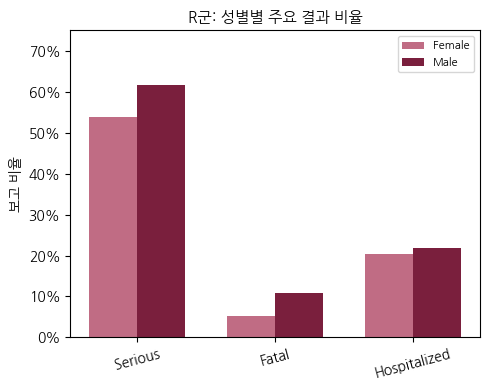

In [4]:
# 시각화 1. 성별별 serious/fatal/hospitalized 비율
plot_df = sex_summary[sex_summary["sex_clean"].isin(["Female", "Male"])].copy()
plot_df = plot_df.set_index("sex_clean").loc[["Female", "Male"]].reset_index()

labels = ["Serious", "Fatal", "Hospitalized"]
female_rates = [plot_df.loc[plot_df["sex_clean"]=="Female", c].iloc[0] for c in ["serious_rate","fatal_rate","hospitalized_rate"]]
male_rates = [plot_df.loc[plot_df["sex_clean"]=="Male", c].iloc[0] for c in ["serious_rate","fatal_rate","hospitalized_rate"]]

x = np.arange(len(labels)); width = 0.35
plt.figure(figsize=(5, 4))
plt.bar(x - width/2, female_rates, width, label="Female", color=BURGUNDY_LIGHT)
plt.bar(x + width/2, male_rates, width, label="Male", color=BURGUNDY)
plt.title("R군: 성별별 주요 결과 비율", fontsize=11)
plt.ylabel("보고 비율")
plt.xticks(x, labels, rotation=15)
plt.ylim(0, 0.75)
percent_axis_y()
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
# H2. 성별 x 병용약물 여부
mf_df["poly_label"] = np.where(mf_df["polypharmacy_6plus"], "Polypharmacy(6+)", "Non-polypharmacy")

sex_poly_summary = (
    mf_df.groupby(["sex_clean", "poly_label"])
    .agg(n=("serious_bool","size"), serious_rate=("serious_bool","mean"),
         fatal_rate=("is_fatal_bool","mean"), hospitalized_rate=("is_hospitalized_bool","mean"))
    .reset_index()
)
display(sex_poly_summary)

for poly_group in ["Non-polypharmacy", "Polypharmacy(6+)"]:
    temp = mf_df[mf_df["poly_label"] == poly_group]
    print("\n==============================")
    print("병용약물 그룹:", poly_group)
    print("==============================")
    for outcome in ["serious_bool", "is_fatal_bool", "is_hospitalized_bool"]:
        chi_square_test(temp, "sex_clean", outcome)
        OR, lower, upper = odds_ratio_ci(temp, "sex_clean", outcome)
        print(f"[OR] Male vs Female - {outcome}: OR={OR:.2f}, 95% CI=({lower:.2f}, {upper:.2f})")

,sex_clean,poly_label,n,serious_rate,fatal_rate,hospitalized_rate
0,Female,Non-polypharmacy,634,0.430599,0.033123,0.145110
1,Female,Polypharmacy(6+),266,0.796992,0.097744,0.345865
2,Male,Non-polypharmacy,343,0.507289,0.072886,0.145773
3,Male,Polypharmacy(6+),144,0.875000,0.194444,0.388889



병용약물 그룹: Non-polypharmacy

[카이제곱 검정]
변수: sex_clean vs serious_bool


serious_bool,False,True
sex_clean,,
Female,361,273
Male,169,174


chi2: 4.969824037096969
p-value: 0.025793271413156533
Cramer's V: 0.07132195256872834
[OR] Male vs Female - serious_bool: OR=1.36, 95% CI=(1.05, 1.77)

[카이제곱 검정]
변수: sex_clean vs is_fatal_bool


is_fatal_bool,False,True
sex_clean,,
Female,613,21
Male,318,25


...

chi2: 3.406567070086596
p-value: 0.06493740737877136
Cramer's V: 0.0911520716766378
[OR] Male vs Female - serious_bool: OR=1.78, 95% CI=(1.00, 3.18)

[카이제곱 검정]
변수: sex_clean vs is_fatal_bool


is_fatal_bool,False,True
sex_clean,,
Female,240,26
Male,116,28


chi2: 6.816851842834475
p-value: 0.009030161392030802
Cramer's V: 0.12894366176494437
[OR] Male vs Female - is_fatal_bool: OR=2.23, 95% CI=(1.25, 3.97)

[카이제곱 검정]
변수: sex_clean vs is_hospitalized_bool


is_hospitalized_bool,False,True
sex_clean,,
Female,174,92
Male,88,56


chi2: 0.5747902377604311
p-value: 0.44836165760276137
Cramer's V: 0.0374423210975466
[OR] Male vs Female - is_hospitalized_bool: OR=1.20, 95% CI=(0.79, 1.83)


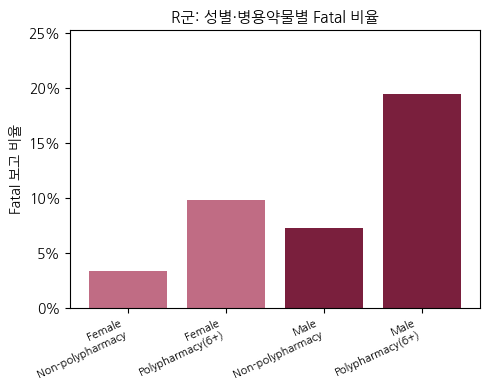

In [6]:
# 시각화 2. 성별 x 병용약물 여부별 fatal 비율
plot_data = sex_poly_summary.copy()
plot_data["group"] = plot_data["sex_clean"] + "\n" + plot_data["poly_label"]

plt.figure(figsize=(5, 4))
plt.bar(plot_data["group"], plot_data["fatal_rate"],
        color=[BURGUNDY_LIGHT if "Female" in x else BURGUNDY for x in plot_data["group"]])
plt.title("R군: 성별·병용약물별 Fatal 비율", fontsize=11)
plt.ylabel("Fatal 보고 비율")
plt.xticks(rotation=25, ha="right", fontsize=8)
plt.ylim(0, max(plot_data["fatal_rate"]) * 1.3)
percent_axis_y()
plt.tight_layout()
plt.show()

In [7]:
# H3. 성별 x 연령군
age_sex_summary = (
    mf_df.groupby(["age_risk_group", "sex_clean"])
    .agg(n=("serious_bool","size"), serious_rate=("serious_bool","mean"),
         fatal_rate=("is_fatal_bool","mean"), hospitalized_rate=("is_hospitalized_bool","mean"),
         polypharmacy_rate=("polypharmacy_6plus","mean"))
    .reset_index()
)
display(age_sex_summary)

for age_group in ["13-40세", "그 외 알려진 연령", "연령 Unknown"]:
    temp = mf_df[mf_df["age_risk_group"] == age_group]
    print("\n==============================")
    print("연령군:", age_group)
    print("==============================")
    if len(temp) > 0 and temp["sex_clean"].nunique() == 2:
        for outcome in ["serious_bool", "is_fatal_bool", "is_hospitalized_bool"]:
            chi_square_test(temp, "sex_clean", outcome)
            OR, lower, upper = odds_ratio_ci(temp, "sex_clean", outcome)
            print(f"[OR] Male vs Female - {outcome}: OR={OR:.2f}, 95% CI=({lower:.2f}, {upper:.2f})")

,age_risk_group,sex_clean,n,serious_rate,fatal_rate,hospitalized_rate,polypharmacy_rate
0,13-40세,Female,160,0.806250,0.081250,0.331250,0.362500
1,13-40세,Male,97,0.876289,0.237113,0.329897,0.412371
2,그 외 알려진 연령,Female,500,0.560000,0.056000,0.226000,0.302000
3,그 외 알려진 연령,Male,286,0.632867,0.097902,0.241259,0.293706
4,연령 Unknown,Female,240,0.316667,0.025000,0.075000,0.237500
5,연령 Unknown,Male,104,0.326923,0.019231,0.048077,0.192308



연령군: 13-40세

[카이제곱 검정]
변수: sex_clean vs serious_bool


serious_bool,False,True
sex_clean,,
Female,31,129
Male,12,85


chi2: 1.6532685790656216
p-value: 0.19851464323256984
Cramer's V: 0.08020568352377552
[OR] Male vs Female - serious_bool: OR=1.70, 95% CI=(0.83, 3.50)

[카이제곱 검정]
변수: sex_clean vs is_fatal_bool


is_fatal_bool,False,True
sex_clean,,
Female,147,13
Male,74,23


...

chi2: 0.0037780168549399725
p-value: 0.9509884300753695
Cramer's V: 0.003314001680212822
[OR] Male vs Female - serious_bool: OR=1.05, 95% CI=(0.64, 1.71)

[카이제곱 검정]
변수: sex_clean vs is_fatal_bool


is_fatal_bool,False,True
sex_clean,,
Female,234,6
Male,102,2


chi2: 0.0
p-value: 1.0
Cramer's V: 0.0
[OR] Male vs Female - is_fatal_bool: OR=0.76, 95% CI=(0.15, 3.85)

[카이제곱 검정]
변수: sex_clean vs is_hospitalized_bool


is_hospitalized_bool,False,True
sex_clean,,
Female,222,18
Male,99,5


chi2: 0.4666819477871895
p-value: 0.49451760110856235
Cramer's V: 0.03683250696258411
[OR] Male vs Female - is_hospitalized_bool: OR=0.62, 95% CI=(0.22, 1.73)


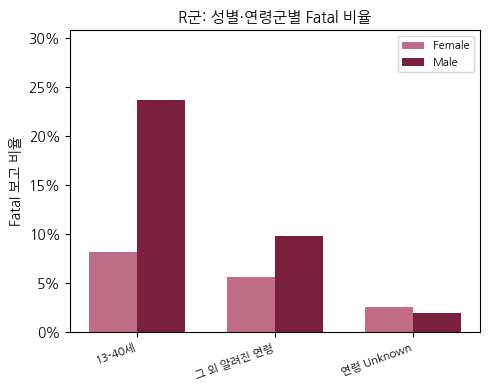

In [8]:
# 시각화 3. 성별 x 연령군별 fatal 비율
age_order = ["13-40세", "그 외 알려진 연령", "연령 Unknown"]
female_vals, male_vals = [], []
for ag in age_order:
    f = age_sex_summary[(age_sex_summary["age_risk_group"]==ag) & (age_sex_summary["sex_clean"]=="Female")]["fatal_rate"]
    m = age_sex_summary[(age_sex_summary["age_risk_group"]==ag) & (age_sex_summary["sex_clean"]=="Male")]["fatal_rate"]
    female_vals.append(f.iloc[0] if len(f) > 0 else 0)
    male_vals.append(m.iloc[0] if len(m) > 0 else 0)

x = np.arange(len(age_order)); width = 0.35
plt.figure(figsize=(5, 4))
plt.bar(x - width/2, female_vals, width, label="Female", color=BURGUNDY_LIGHT)
plt.bar(x + width/2, male_vals, width, label="Male", color=BURGUNDY)
plt.title("R군: 성별·연령군별 Fatal 비율", fontsize=11)
plt.ylabel("Fatal 보고 비율")
plt.xticks(x, age_order, rotation=20, ha="right", fontsize=8)
plt.ylim(0, max(male_vals + female_vals) * 1.3)
percent_axis_y()
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
# H4. 성별별 부작용 반응 유형 분류
reaction_text = (mf_df["reactions"].fillna("") + "; " + mf_df["primary_reaction"].fillna("")).str.upper()

mf_df["rx_interaction_error"] = reaction_text.str.contains(
    "DRUG INTERACTION|INTERACTION|OVERDOSE|EXTRA DOSE|PRODUCT USE ISSUE|WRONG|MEDICATION ERROR|TOXICITY|ABUSE|MISUSE", regex=True)
mf_df["rx_hypersensitivity"] = reaction_text.str.contains(
    "HYPERSENSITIVITY|ALLERG|ANAPHYLA|URTICARIA|RASH|ANGIOEDEMA", regex=True)
mf_df["rx_sleep_dizzy"] = reaction_text.str.contains(
    "SOMNOLENCE|DIZZINESS|SEDATION|INSOMNIA|SLEEP|FATIGUE|IMPAIRED|CONFUS", regex=True)
mf_df["rx_death_suicide_critical"] = reaction_text.str.contains(
    "DEATH|FATAL|COMPLETED SUICIDE|SUICIDE|LIFE THREAT|CARDIAC|SEIZURE|COMA", regex=True)
mf_df["rx_ineffective"] = reaction_text.str.contains(
    "DRUG INEFFECTIVE|THERAPEUTIC PRODUCT EFFECT|CONDITION AGGRAVATED|SYMPTOM PERSIST", regex=True)

reaction_cols = {
    "상호작용/오남용/투약오류": "rx_interaction_error",
    "알레르기/과민반응": "rx_hypersensitivity",
    "졸림/어지러움/수면": "rx_sleep_dizzy",
    "사망/자살/중증 신호": "rx_death_suicide_critical",
    "약효 부족/치료실패": "rx_ineffective"
}

reaction_rate_rows = []
for label, col in reaction_cols.items():
    female_rate = mf_df.loc[mf_df["sex_clean"]=="Female", col].mean()
    male_rate = mf_df.loc[mf_df["sex_clean"]=="Male", col].mean()
    table, chi2, p, v = chi_square_test(mf_df, "sex_clean", col)
    OR, lower, upper = odds_ratio_ci(mf_df, "sex_clean", col)
    reaction_rate_rows.append({
        "reaction_type": label, "female_rate": female_rate, "male_rate": male_rate,
        "male_vs_female_OR": OR, "CI_lower": lower, "CI_upper": upper, "p_value": p
    })

reaction_rate_df = pd.DataFrame(reaction_rate_rows)
display(reaction_rate_df)


[카이제곱 검정]
변수: sex_clean vs rx_interaction_error


rx_interaction_error,False,True
sex_clean,,
Female,741,159
Male,369,118


chi2: 8.111391511607014
p-value: 0.004398794728169417
Cramer's V: 0.07647323309285024

[카이제곱 검정]
변수: sex_clean vs rx_hypersensitivity


rx_hypersensitivity,False,True
sex_clean,,
Female,787,113
Male,458,29


chi2: 14.272491152538546
p-value: 0.0001581594869241108
Cramer's V: 0.10144056528774163

[카이제곱 검정]
변수: sex_clean vs rx_sleep_dizzy


...

rx_death_suicide_critical,False,True
sex_clean,,
Female,851,49
Male,437,50


chi2: 10.37204599477725
p-value: 0.0012793768625435405
Cramer's V: 0.08647568013647831

[카이제곱 검정]
변수: sex_clean vs rx_ineffective


rx_ineffective,False,True
sex_clean,,
Female,733,167
Male,399,88


chi2: 0.02259044452160236
p-value: 0.8805270025535578
Cramer's V: 0.0040357490932620204


,reaction_type,female_rate,male_rate,male_vs_female_OR,CI_lower,CI_upper,p_value
0,상호작용/오남용/투약오류,0.176667,0.242300,1.490310,1.138914,1.950125,0.004399
1,알레르기/과민반응,0.125556,0.059548,0.440990,0.288609,0.673827,0.000158
2,졸림/어지러움/수면,0.143333,0.123203,0.839824,0.604792,1.166192,0.336515
3,사망/자살/중증 신호,0.054444,0.102669,1.987111,1.318044,2.995809,0.001279
4,약효 부족/치료실패,0.185556,0.180698,0.968049,0.727601,1.287957,0.880527


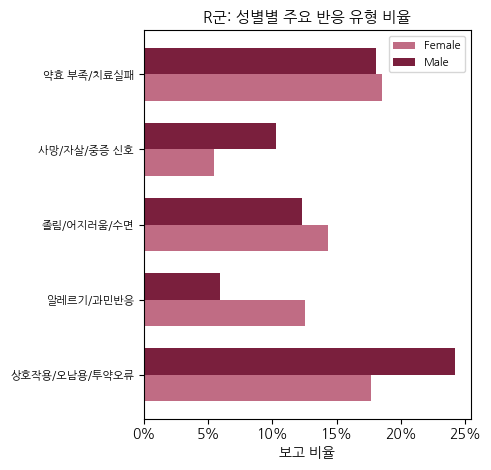

In [10]:
# 시각화 4. 성별별 주요 반응 유형 비율
labels = reaction_rate_df["reaction_type"].tolist()
female_rates = reaction_rate_df["female_rate"].tolist()
male_rates = reaction_rate_df["male_rate"].tolist()

y = np.arange(len(labels)); height = 0.35
plt.figure(figsize=(5, 4.8))
plt.barh(y - height/2, female_rates, height, label="Female", color=BURGUNDY_LIGHT)
plt.barh(y + height/2, male_rates, height, label="Male", color=BURGUNDY)
plt.title("R군: 성별별 주요 반응 유형 비율", fontsize=11)
plt.xlabel("보고 비율")
plt.yticks(y, labels, fontsize=8)
percent_axis_x()
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
# H5. 보정 로지스틱 회귀 (성별 효과가 병용약물, 연령, 반응 수 때문인지 확인)
model_df = mf_df.copy()
model_df["male"] = (model_df["sex_clean"] == "Male").astype(int)
model_df["poly"] = model_df["polypharmacy_6plus"].astype(int)
model_df["age_13_40"] = model_df["patient_age_years"].between(13, 40).astype(int)

model_cols = ["serious_bool", "is_fatal_bool", "is_hospitalized_bool", "male", "poly", "age_13_40", "num_reactions"]
model_df = model_df[model_cols].dropna().copy()
for col in ["serious_bool", "is_fatal_bool", "is_hospitalized_bool"]:
    model_df[col] = model_df[col].astype(int)

results = []
for outcome in ["serious_bool", "is_fatal_bool", "is_hospitalized_bool"]:
    formula = f"{outcome} ~ male + poly + age_13_40 + num_reactions"
    model = smf.logit(formula, data=model_df).fit(disp=False)
    params, conf, pvals = model.params, model.conf_int(), model.pvalues
    for var in ["male", "poly", "age_13_40", "num_reactions"]:
        results.append({
            "outcome": outcome, "variable": var,
            "adjusted_OR": math.exp(params[var]),
            "CI_lower": math.exp(conf.loc[var, 0]), "CI_upper": math.exp(conf.loc[var, 1]),
            "p_value": pvals[var]
        })

adjusted_results = pd.DataFrame(results)
display(adjusted_results)

,outcome,variable,adjusted_OR,CI_lower,CI_upper,p_value
0,serious_bool,male,1.566444,1.213462,2.022104,5.707794e-04
1,serious_bool,poly,3.719745,2.733156,5.062464,6.593681e-17
2,serious_bool,age_13_40,4.531859,3.131954,6.557486,1.091192e-15
3,serious_bool,num_reactions,1.217433,1.156481,1.281598,6.020677e-14
4,is_fatal_bool,male,2.321546,1.520895,3.543689,9.497747e-05
5,is_fatal_bool,poly,2.614762,1.704147,4.011965,1.080318e-05
6,is_fatal_bool,age_13_40,2.483697,1.587618,3.885538,6.765032e-05
7,is_fatal_bool,num_reactions,1.018631,1.004846,1.032606,7.924563e-03
8,is_hospitalized_bool,male,1.148148,0.862288,1.528776,3.443017e-01
9,is_hospitalized_bool,poly,2.586788,1.943371,3.443229,7.347126e-11


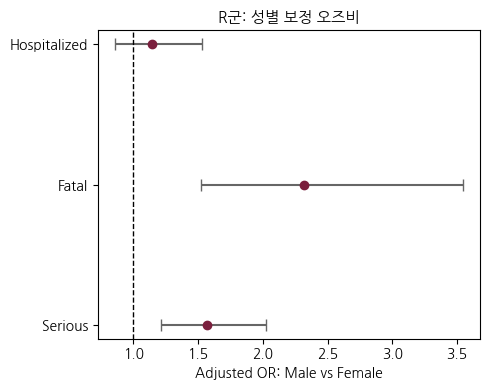

In [12]:
# 시각화 5. 성별 보정 OR
sex_adjusted = adjusted_results[adjusted_results["variable"] == "male"].copy()
sex_adjusted["outcome_label"] = sex_adjusted["outcome"].map({
    "serious_bool": "Serious", "is_fatal_bool": "Fatal", "is_hospitalized_bool": "Hospitalized"
})

plt.figure(figsize=(5, 4))
x = sex_adjusted["adjusted_OR"]; y = np.arange(len(sex_adjusted))
xerr_lower = x - sex_adjusted["CI_lower"]; xerr_upper = sex_adjusted["CI_upper"] - x
plt.errorbar(x, y, xerr=[xerr_lower, xerr_upper], fmt="o", color=BURGUNDY, ecolor=GRAY, capsize=4)
plt.axvline(1, color="black", linestyle="--", linewidth=1)
plt.yticks(y, sex_adjusted["outcome_label"])
plt.xlabel("Adjusted OR: Male vs Female")
plt.title("R군: 성별 보정 오즈비", fontsize=11)
plt.tight_layout()
plt.show()

In [13]:
# H3 수정본: 세부 연령대(0-2세 ~ 81세 이상)별 성별 차이 재분석
def make_age_fine(age):
    if pd.isna(age) or age < 0 or age > 120: return "연령 Unknown"
    elif age <= 2: return "0-2세"
    elif age <= 12: return "3-12세"
    elif age <= 18: return "13-18세"
    elif age <= 29: return "19-29세"
    elif age <= 40: return "30-40세"
    elif age <= 50: return "41-50세"
    elif age <= 65: return "51-65세"
    elif age <= 75: return "66-75세"
    elif age <= 80: return "76-80세"
    else: return "81세 이상"

mf_df["age_fine"] = mf_df["patient_age_years"].apply(make_age_fine)
age_order = ["0-2세","3-12세","13-18세","19-29세","30-40세","41-50세","51-65세","66-75세","76-80세","81세 이상","연령 Unknown"]
mf_df["age_fine"] = pd.Categorical(mf_df["age_fine"], categories=age_order, ordered=True)

print("R군 남성/여성 분석 대상 건수:", len(mf_df))
print("\n세부 연령대별 건수")
display(mf_df.groupby(["age_fine", "sex_clean"], observed=False).size().reset_index(name="n"))

R군 남성/여성 분석 대상 건수: 1387

세부 연령대별 건수


,age_fine,sex_clean,n
0,0-2세,Female,7
1,0-2세,Male,16
2,3-12세,Female,35
3,3-12세,Male,19
4,13-18세,Female,20
5,13-18세,Male,17
6,19-29세,Female,55
7,19-29세,Male,33
8,30-40세,Female,85
9,30-40세,Male,47


In [14]:
# 세부 연령대 x 성별 요약표
age_sex_detail_summary = (
    mf_df.groupby(["age_fine", "sex_clean"], observed=False)
    .agg(n=("serious_bool","size"), serious_rate=("serious_bool","mean"),
         fatal_rate=("is_fatal_bool","mean"), hospitalized_rate=("is_hospitalized_bool","mean"),
         life_threat_rate=("is_life_threat_bool","mean"), polypharmacy_rate=("polypharmacy_6plus","mean"),
         median_num_reactions=("num_reactions","median"))
    .reset_index()
)
age_sex_detail_summary["serious_pct"] = age_sex_detail_summary["serious_rate"] * 100
age_sex_detail_summary["fatal_pct"] = age_sex_detail_summary["fatal_rate"] * 100
age_sex_detail_summary["hospitalized_pct"] = age_sex_detail_summary["hospitalized_rate"] * 100
age_sex_detail_summary["polypharmacy_pct"] = age_sex_detail_summary["polypharmacy_rate"] * 100
display(age_sex_detail_summary)

,age_fine,sex_clean,n,serious_rate,fatal_rate,hospitalized_rate,life_threat_rate,polypharmacy_rate,median_num_reactions,serious_pct,fatal_pct,hospitalized_pct,polypharmacy_pct
0,0-2세,Female,7,0.714286,0.142857,0.428571,0.142857,0.285714,3.0,71.428571,14.285714,42.857143,28.571429
1,0-2세,Male,16,0.500000,0.125000,0.125000,0.000000,0.062500,2.0,50.000000,12.500000,12.500000,6.250000
2,3-12세,Female,35,0.485714,0.000000,0.114286,0.000000,0.114286,2.0,48.571429,0.000000,11.428571,11.428571
3,3-12세,Male,19,0.368421,0.105263,0.000000,0.000000,0.052632,2.0,36.842105,10.526316,0.000000,5.263158
4,13-18세,Female,20,0.850000,0.000000,0.400000,0.100000,0.250000,3.5,85.000000,0.000000,40.000000,25.000000
5,13-18세,Male,17,0.941176,0.117647,0.529412,0.058824,0.235294,6.0,94.117647,11.764706,52.941176,23.529412
6,19-29세,Female,55,0.836364,0.127273,0.400000,0.181818,0.381818,4.0,83.636364,12.727273,40.000000,38.181818
7,19-29세,Male,33,0.818182,0.333333,0.363636,0.030303,0.393939,3.0,81.818182,33.333333,36.363636,39.393939
8,30-40세,Female,85,0.776471,0.070588,0.270588,0.082353,0.376471,3.0,77.647059,7.058824,27.058824,37.647059
9,30-40세,Male,47,0.893617,0.212766,0.234043,0.021277,0.489362,3.0,89.361702,21.276596,23.404255,48.936170


In [15]:
# 세부 연령대별 남성 vs 여성 통계검정 (기대빈도 낮으면 Fisher's exact로 자동 전환)
def odds_ratio_ci_counts(a, b, c, d):
    aa, bb, cc, dd = a, b, c, d
    if min(aa, bb, cc, dd) == 0:
        aa, bb, cc, dd = aa+0.5, bb+0.5, cc+0.5, dd+0.5
    OR = (aa * dd) / (bb * cc)
    se = math.sqrt(1/aa + 1/bb + 1/cc + 1/dd)
    return OR, math.exp(math.log(OR) - 1.96*se), math.exp(math.log(OR) + 1.96*se)

def sex_test_by_age(data, outcome_col):
    rows = []
    for age in age_order:
        temp = data[data["age_fine"].astype(str) == age].copy()
        if len(temp) == 0 or temp["sex_clean"].nunique() < 2:
            continue
        male_event = ((temp["sex_clean"]=="Male") & (temp[outcome_col])).sum()
        male_nonevent = ((temp["sex_clean"]=="Male") & (~temp[outcome_col])).sum()
        female_event = ((temp["sex_clean"]=="Female") & (temp[outcome_col])).sum()
        female_nonevent = ((temp["sex_clean"]=="Female") & (~temp[outcome_col])).sum()
        table = np.array([[male_event, male_nonevent], [female_event, female_nonevent]])
        OR, lower, upper = odds_ratio_ci_counts(male_event, male_nonevent, female_event, female_nonevent)
        try:
            chi2, p_chi, dof, expected = chi2_contingency(table)
            if (expected < 5).any() or (table < 5).any():
                _, p_value = fisher_exact(table); test_name = "Fisher exact"
            else:
                p_value = p_chi; test_name = "Chi-square"
        except Exception:
            p_value = np.nan; test_name = "검정 불가"
        female_n = female_event + female_nonevent
        male_n = male_event + male_nonevent
        rows.append({
            "age_fine": age, "outcome": outcome_col, "female_n": female_n, "male_n": male_n,
            "female_event": female_event, "male_event": male_event,
            "female_rate": female_event/female_n if female_n>0 else np.nan,
            "male_rate": male_event/male_n if male_n>0 else np.nan,
            "male_vs_female_OR": OR, "CI_lower": lower, "CI_upper": upper,
            "p_value": p_value, "test": test_name
        })
    return pd.DataFrame(rows)

serious_age_test = sex_test_by_age(mf_df, "serious_bool")
fatal_age_test = sex_test_by_age(mf_df, "is_fatal_bool")
hospital_age_test = sex_test_by_age(mf_df, "is_hospitalized_bool")

print("세부 연령대별 Serious 성별 차이"); display(serious_age_test)
print("세부 연령대별 Fatal 성별 차이"); display(fatal_age_test)
print("세부 연령대별 Hospitalized 성별 차이"); display(hospital_age_test)

세부 연령대별 Serious 성별 차이


,age_fine,outcome,female_n,male_n,female_event,male_event,female_rate,male_rate,male_vs_female_OR,CI_lower,CI_upper,p_value,test
0,0-2세,serious_bool,7,16,5,8,0.714286,0.500000,0.400000,0.059210,2.702240,0.405034,Fisher exact
1,3-12세,serious_bool,35,19,17,7,0.485714,0.368421,0.617647,0.196781,1.938637,0.588084,Chi-square
2,13-18세,serious_bool,20,17,17,16,0.850000,0.941176,2.823529,0.265550,30.021901,0.608752,Fisher exact
3,19-29세,serious_bool,55,33,46,27,0.836364,0.818182,0.880435,0.282409,2.744834,1.000000,Chi-square
4,30-40세,serious_bool,85,47,66,42,0.776471,0.893617,2.418182,0.839146,6.968518,0.151207,Chi-square
5,41-50세,serious_bool,87,37,68,32,0.781609,0.864865,1.788235,0.612763,5.218631,0.409201,Chi-square
6,51-65세,serious_bool,155,78,85,56,0.548387,0.717949,2.096257,1.166772,3.766197,0.018438,Chi-square
7,66-75세,serious_bool,103,64,53,43,0.514563,0.671875,1.931716,1.009152,3.697684,0.066025,Chi-square
8,76-80세,serious_bool,35,30,16,15,0.457143,0.500000,1.187500,0.447027,3.154522,0.923682,Chi-square
9,81세 이상,serious_bool,78,42,36,20,0.461538,0.476190,1.060606,0.500203,2.248859,1.000000,Chi-square


세부 연령대별 Fatal 성별 차이


,age_fine,outcome,female_n,male_n,female_event,male_event,female_rate,male_rate,male_vs_female_OR,CI_lower,CI_upper,p_value,test
0,0-2세,is_fatal_bool,7,16,1,2,0.142857,0.125000,0.857143,0.064690,11.357194,1.000000,Fisher exact
1,3-12세,is_fatal_bool,35,19,0,2,0.000000,0.105263,10.142857,0.461559,222.891393,0.119497,Fisher exact
2,13-18세,is_fatal_bool,20,17,0,2,0.000000,0.117647,6.612903,0.295750,147.862869,0.204204,Fisher exact
3,19-29세,is_fatal_bool,55,33,7,11,0.127273,0.333333,3.428571,1.171764,10.031967,0.040652,Chi-square
4,30-40세,is_fatal_bool,85,47,6,10,0.070588,0.212766,3.558559,1.202634,10.529673,0.034168,Chi-square
5,41-50세,is_fatal_bool,87,37,8,3,0.091954,0.081081,0.871324,0.217789,3.485970,1.000000,Fisher exact
6,51-65세,is_fatal_bool,155,78,4,14,0.025806,0.179487,8.257812,2.617269,26.054436,0.000081,Fisher exact
7,66-75세,is_fatal_bool,103,64,7,4,0.067961,0.062500,0.914286,0.256726,3.256077,1.000000,Fisher exact
8,76-80세,is_fatal_bool,35,30,2,1,0.057143,0.033333,0.568966,0.049010,6.605192,1.000000,Fisher exact
9,81세 이상,is_fatal_bool,78,42,6,2,0.076923,0.047619,0.600000,0.115652,3.112800,0.711572,Fisher exact


세부 연령대별 Hospitalized 성별 차이


,age_fine,outcome,female_n,male_n,female_event,male_event,female_rate,male_rate,male_vs_female_OR,CI_lower,CI_upper,p_value,test
0,0-2세,is_hospitalized_bool,7,16,3,2,0.428571,0.125000,0.190476,0.023181,1.565155,0.142084,Fisher exact
1,3-12세,is_hospitalized_bool,35,19,4,0,0.114286,0.000000,0.179487,0.009154,3.519175,0.285062,Fisher exact
2,13-18세,is_hospitalized_bool,20,17,8,9,0.400000,0.529412,1.687500,0.456842,6.233356,0.648241,Chi-square
3,19-29세,is_hospitalized_bool,55,33,22,12,0.400000,0.363636,0.857143,0.351596,2.089596,0.909987,Chi-square
4,30-40세,is_hospitalized_bool,85,47,23,11,0.270588,0.234043,0.823671,0.360022,1.884428,0.801101,Chi-square
5,41-50세,is_hospitalized_bool,87,37,30,11,0.344828,0.297297,0.803846,0.349771,1.847406,0.759476,Chi-square
6,51-65세,is_hospitalized_bool,155,78,32,22,0.206452,0.282051,1.510045,0.805773,2.829874,0.260129,Chi-square
7,66-75세,is_hospitalized_bool,103,64,22,12,0.213592,0.187500,0.849650,0.387584,1.862578,0.834079,Chi-square
8,76-80세,is_hospitalized_bool,35,30,8,11,0.228571,0.366667,1.953947,0.661253,5.773749,0.343740,Chi-square
9,81세 이상,is_hospitalized_bool,78,42,14,11,0.179487,0.261905,1.622120,0.660391,3.984415,0.409531,Chi-square


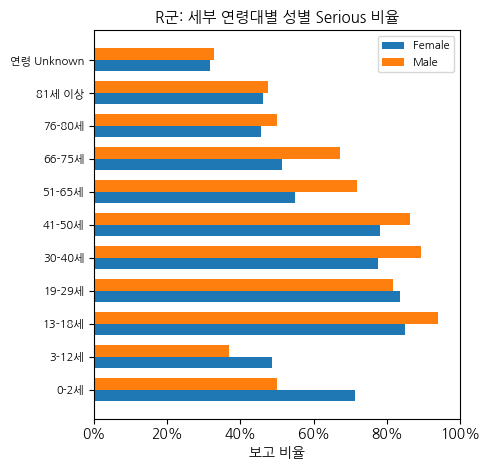

In [16]:
# 시각화: 세부 연령대별 성별 비율 (Serious / Fatal / Hospitalized)
def plot_age_sex_rate(test_df, title):
    plot_df = test_df.copy()
    plot_df["age_fine"] = pd.Categorical(plot_df["age_fine"], categories=age_order, ordered=True)
    plot_df = plot_df.sort_values("age_fine")
    y = np.arange(len(plot_df)); height = 0.35
    plt.figure(figsize=(5, 4.8))
    plt.barh(y - height/2, plot_df["female_rate"], height, label="Female")
    plt.barh(y + height/2, plot_df["male_rate"], height, label="Male")
    plt.yticks(y, plot_df["age_fine"], fontsize=8)
    plt.xlabel("보고 비율")
    plt.title(title, fontsize=11)
    plt.xlim(0, 1)
    plt.gca().xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_age_sex_rate(serious_age_test, "R군: 세부 연령대별 성별 Serious 비율")

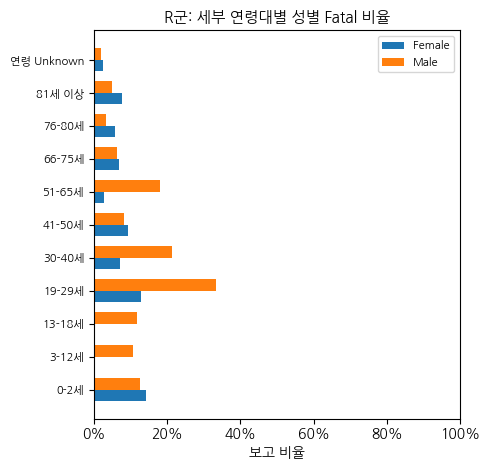

In [17]:
plot_age_sex_rate(fatal_age_test, "R군: 세부 연령대별 성별 Fatal 비율")

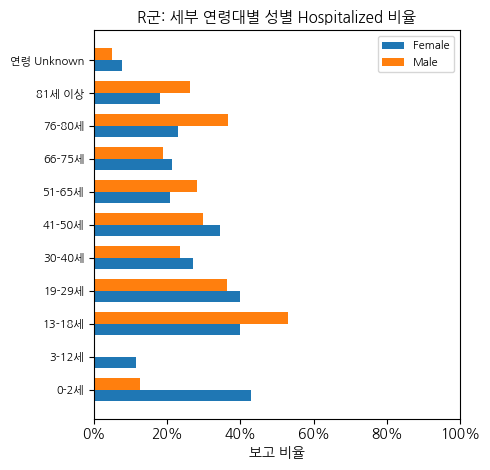

In [18]:
plot_age_sex_rate(hospital_age_test, "R군: 세부 연령대별 성별 Hospitalized 비율")